In [392]:
import pandas
import math

In [394]:
df = pandas.read_csv('company_directorships.csv')
df.software_background = df.software_background.map(lambda x: x == 't')
df.sample(5)

,company_name,cikcode,director_name,software_background,start_date,end_date
698,AMREP CORP.,6207,"EDWARD B. CLOUES, II",False,2007-08-23,2024-08-01
1880,CANADIAN PACIFIC KANSAS CITY LTD/CN,16875,K.E. CREEL,False,2016-02-29,2017-03-16
3789,ELECTRONIC ARTS INC.,712515,ANDREW WILSON,False,2019-06-21,2024-06-14
6336,Invesco Bond Fund,5094,ANTHONY J. LACAVA,False,2019-07-05,2019-07-05
11892,TRANS LUX Corp,99106,YANG LIU,False,2019-07-09,2020-08-25


In [395]:
compensation_and_demographics_raw = pandas.read_csv('director-details.csv')
compensation_and_demographics_raw['NAME'] = compensation_and_demographics_raw.name.str.upper()

def most_common(series):
    mode_values = series.mode()
    if len(mode_values) > 0:
        return mode_values[0]
    return None

# First fix Named Aggregation for Demographics
    
# compensation_and_demographics = pandas.DataFrame({
#     'age': compensation_and_demographics_raw.groupby('NAME').age.max(),
#     'compensation': compensation_and_demographics_raw.groupby('NAME').compensation.sum(),
#     'gender': compensation_and_demographics_raw.groupby('NAME').gender.agg(most_common)
# })
# compensation_and_demographics['log_compensation'] = (1 + compensation_and_demographics.compensation).map(math.log10)
# compensation_and_demographics

In [397]:
# Repair 1. Named Aggregation for Demographics
import numpy as np

compensation_and_demographics = (
    compensation_and_demographics_raw
      .groupby('NAME')
      .agg(
        age=pandas.NamedAgg(column='age', aggfunc='max'),
        compensation=pandas.NamedAgg(column='compensation', aggfunc='sum'),
        gender=pandas.NamedAgg(
          column='gender',
          aggfunc=lambda x: x.mode()[0] if not x.mode().empty else np.nan
        )
      )
)
# vectorized log transform
compensation_and_demographics['log_compensation'] = np.log10(
    compensation_and_demographics['compensation'] + 1
)

compensation_and_demographics

,age,compensation,gender,log_compensation
NAME,,,,
A. CATHERINE NGO,64,1006154,female,6.002665
A. EUGENE WASHINGTON,70,324871,male,5.511712
A. F. PETROCELLI,80,47000,male,4.672107
A. FARAZ ABBASI,52,113631,male,5.055501
A. LARRY CHAPMAN,78,259500,male,5.414139
...,...,...,...,...
ZACKARY IRANI,58,360103,male,5.556428
ZAHID AFZAL,62,0,male,0.000000
ZENA SRIVATSA ARNOLD,46,189960,female,5.278664


In [398]:
compensation_and_demographics.gender.value_counts(dropna=False)

gender
male       3850
female     1550
NaN          19
unknown       2
Name: count, dtype: int64

In [399]:
directorship_counts = df.groupby('director_name').company_name.nunique().sort_values()
directorship_counts

director_name
A CHARLENE SULLIVAN, PH.D.     1
MICHAEL L. KUTA                1
MICHAEL L. LARUSSO             1
MICHAEL L. MILLER              1
MICHAEL L. OWENS               1
                              ..
MARTIN L. FLANAGAN            13
ANN BARNETT STERN             13
TERESA M. RESSEL              13
BRUCE L. CROCKETT             13
ALBERT R. DOWDEN              14
Name: company_name, Length: 11827, dtype: int64

In [401]:
# directorship_counts.value_counts().sort_index().map(math.log10).plot()

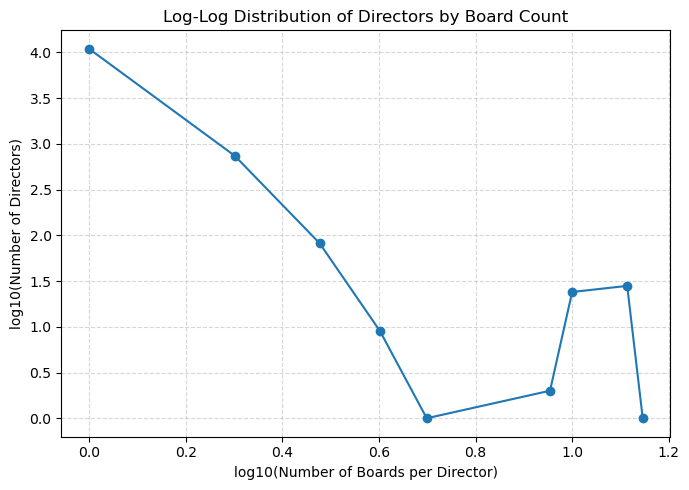

In [402]:
#Repair 2 Enhance Log-Log Board-Count Distribution Plot task 2

import matplotlib.pyplot as plt
import numpy as np

# finding frequency of each board_count
freq = board_counts.value_counts().sort_index()

# preparing the axes
x = freq.index.values         # number of boards
y = freq.values               # number of directors
logx = np.log10(x)            # vectorized log of board counts
logy = np.log10(y)            # vectorized log of frequencies

# plot a log-log line chart
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(logx, logy, marker='o', linestyle='-')
ax.set_title('Log-Log Distribution of Directors by Board Count')
ax.set_xlabel('log10(Number of Boards per Director)')
ax.set_ylabel('log10(Number of Directors)')
ax.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [403]:
import networkx
import networkx.algorithms
graph = networkx.Graph()

In [404]:
people = []
companies = []
for company_name, director_name in zip(df.company_name, df.director_name):
    graph.add_edge(company_name, director_name)
    people.append(director_name)
    companies.append(company_name)

In [405]:
biggest_connected_graph = graph.subgraph(list(networkx.connected_components(graph))[0])

In [ ]:
%%time
centrality = pandas.DataFrame({
    'eigen': pandas.Series(networkx.eigenvector_centrality(biggest_connected_graph)),
    'degree': pandas.Series(networkx.algorithms.degree_centrality(biggest_connected_graph)),
    'betweenness': networkx.betweenness_centrality(biggest_connected_graph)
})
centrality['is_person'] = centrality.index.map(lambda x: x in people)

In [ ]:
people_df = centrality[centrality.is_person].merge(compensation_and_demographics, left_index=True, right_index=True)

In [ ]:
people_df.sort_values('eigen', ascending=False)

In [ ]:
df[df.director_name == 'ELIZABETH KRENTZMAN']

In [ ]:
import sklearn.cluster

In [ ]:
import sklearn.preprocessing


# robust_scaler = sklearn.preprocessing.RobustScaler()
# age_and_demographics_scaled = robust_scaler.fit_transform(people_df[['age', 'log_compensation', 'degree', 'eigen']])


In [ ]:
# dbscan = sklearn.cluster.DBSCAN(eps=0.4)
# people_df['cluster_id'] = dbscan.fit_predict(age_and_demographics_scaled)
# people_df.cluster_id.value_counts()

In [ ]:
# repair 3. Validate & Clean Clustering Inputs 
features = ['age','log_compensation','degree','eigen',]

# 1) Fail fast on any missing
na_counts = people_df[features].isna().sum()
if na_counts.any():
    raise ValueError(
      "Missing values in clustering features:\n" +
      na_counts[na_counts>0].to_string()
    )

# 2) Scale & cluster
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

scaler = RobustScaler()
scaled = scaler.fit_transform(people_df[features])

people_df['cluster_id'] = DBSCAN(eps=0.4).fit_predict(scaled)


In [ ]:
people_df.plot.scatter(x='age', y='log_compensation', c='cluster_id', cmap="rainbow", s=4)

In [ ]:
# repair 4 Enhancing Age vs Scatter Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(
    people_df['age'],
    people_df['log_compensation'],
    c=people_df['cluster_id'],
    cmap='viridis',
    s=30,
    alpha=0.7,
    edgecolor='w'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Cluster ID', rotation=270, labelpad=15)

ax.set_title('Age vs Log Compensation by Cluster')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Log10(Compensation + 1)')
plt.tight_layout()
plt.show()


In [ ]:
people_df.loc['ELIZABETH KRENTZMAN']

# Task 5(a) Visualization for the Presentation

## How Many Directors Fall Into Each Prestige Tier?

In [ ]:
import matplotlib.pyplot as plt

# Assuming `people_df` is already loaded with an 'eigen' column.

# Calculate quartiles for eigenvector centrality
eigen_quartiles = people_df['eigen'].quantile([0.25, 0.75])

# Function to assign tier based on quartiles
def eigen_tier(x):
    if x >= eigen_quartiles.loc[0.75]:
        return 'High Credibility'
    elif x <= eigen_quartiles.loc[0.25]:
        return 'Low Credibility'
    else:
        return 'Medium Credibility'

# Apply tier categorization
people_df['eigen_tier'] = people_df['eigen'].apply(eigen_tier)

# Count directors in each tier
eigen_tier_counts = people_df['eigen_tier'].value_counts().reindex(
    ['High Credibility', 'Medium Credibility', 'Low Credibility']
)

# Plot the overview
fig, ax = plt.subplots()
ax.bar(eigen_tier_counts.index, eigen_tier_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_xlabel('Eigenvector Centrality Tier')
ax.set_ylabel('Number of Directors')
ax.set_title('Director Counts by Credibility Tier')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Age Distribution of Company Directors

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
# Plot age histogram
ax.hist(people_df['age'].dropna(), bins=10, edgecolor='black', alpha=0.7)

# Median line
median_age = people_df['age'].median()
ax.axvline(median_age, color='red', linestyle='--', linewidth=2,
           label=f'Median Age = {median_age:.1f}')

# Labels & title
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Directors')
ax.set_title('Age Distribution of Company Directors')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Impact by Role

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Pick the top 5 roles by frequency
top_roles = people_df['role'].value_counts().index[:5]

# 2. Compute average centrality metrics
avg_metrics = (
    people_df[people_df['role'].isin(top_roles)]
      .groupby('role')[['degree', 'eigen', 'betweenness']]
      .mean()
)

# 3. Set up positions
x = np.arange(len(top_roles))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# 4. Plot Degree & Betweenness on left axis
bars_deg = ax1.bar(x - width/2, avg_metrics['degree'], width, label='Degree',      color='tab:blue')
bars_bet = ax1.bar(x + width/2, avg_metrics['betweenness'], width, label='Betweenness', color='tab:green')

# 5. Plot Eigenvector on right axis
bars_eig = ax2.bar(x + 3*width/2, avg_metrics['eigen'], width, label='Eigenvector', color='tab:orange')

# 6. Tidy up ticks & labels
ax1.set_xticks(x)
ax1.set_xticklabels(top_roles, rotation=60, ha='right', fontsize=8)
ax1.set_ylabel('Degree & Betweenness')
ax2.set_ylabel('Eigenvector')
ax1.set_title('Role Impact: Average Centrality Metrics by Role')
plt.subplots_adjust(bottom=0.25)

# 7. Combined legend
handles = [bars_deg, bars_bet, bars_eig]
labels  = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper left')

# 8. Grid & layout
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Top 10 Directors by Brokerage Power

In [ ]:
import matplotlib.pyplot as plt

# Assumes `people_df` exists with 'betweenness' and index as director names

# 1. Select top 10 directors by betweenness centrality
top10_brokers = people_df['betweenness'].nlargest(10)

# 2. Create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 6))
top10_brokers.sort_values().plot.barh(ax=ax, edgecolor='black', alpha=0.7)

# 3. Labels and title
ax.set_xlabel('Betweenness Centrality')
ax.set_ylabel('Director Name')
ax.set_title('Top 10 Directors by Brokerage Power')

plt.tight_layout()
plt.show()
